In [ ]:
# autocorrelation is always gonna be "1"
# in the context of time series itis useful but in other context it is not useful

# AR model "P" value can be visualize with the help of the "PACF" graph
# MA models hyperparamter valuecan be visualize with the help of "ACF" graph

#ARIMA : auto regressive integreted moving average
# so in ARIMA(p,d,q) : p and q is d is differencing

In [ ]:
# if the sse is equals to 0 means the actual value  andthe predicted value is the same
# model is good fit
# ARIMA(2,0,2) so those are of p and of q and "d" is differencing parameter so it is used always 0 becaue we  will always gonna be stablize the mean
# first so it will be done here

#Model summary:
# plot the data and identify any patterns
# if necessary transformthe data to stabilize the "variance"
# if the data is non stationary take the differences of the data until the data are stationary
# examine the ACF and PACF is an ARIMA(p,d,0) or ARIMA(0,d,q) model appropriate
# try your choosen model(s) and use the AIC to search for better model
# check the residuals from your choosen model by plotting the ACF of the residuals if they do not look like white noise, try a modified model
# once the residuals looks like white noise calculate forecasts
# for steps 3-5 use Auto arima algorithm
# uses a stepwise search to traverse the model space and identifies the optimal model

#Information criteria:
# a measure of quality of a statistical model which attempts to accurately represent the process that generated the time series
#information criteria estimatesthe information lost by a model
# Akaike information criterion(AIC)
# Bayesian information criterion(BIC)
#They consist of a goodness of fit term plus a penalty to control overfitting

# the lower the AIC or BIC so that model is good

#handson of :Time series

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
df['#Passengers'].unique()

array([112, 118, 132, 129, 121, 135, 148, 136, 119, 104, 115, 126, 141,
       125, 149, 170, 158, 133, 114, 140, 145, 150, 178, 163, 172, 199,
       184, 162, 146, 166, 171, 180, 193, 181, 183, 218, 230, 242, 209,
       191, 194, 196, 236, 235, 229, 243, 264, 272, 237, 211, 201, 204,
       188, 227, 234, 302, 293, 259, 203, 233, 267, 269, 270, 315, 364,
       347, 312, 274, 278, 284, 277, 317, 313, 318, 374, 413, 405, 355,
       306, 271, 301, 356, 348, 422, 465, 467, 404, 305, 336, 340, 362,
       363, 435, 491, 505, 359, 310, 337, 360, 342, 406, 396, 420, 472,
       548, 559, 463, 407, 417, 391, 419, 461, 535, 622, 606, 508, 390,
       432])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
df.isnull().sum()

,0
Month,0
#Passengers,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# we have the data from january 1949 to 1960 december

In [ ]:
df['Month'] = pd.to_datetime(df['Month'])

In [ ]:
df.info() # so successfully converted the object datatype of the model to the datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


# so in the time series we can work with the only one columns so from the above one we can just make the "month" columns to the index columns rather then removing it

In [ ]:
df.set_index("Month",inplace=True)

In [ ]:
df.head(2) # so now convertedthe month column into the index of the columns

,#Passengers
Month,
1949-01-01,112
1949-02-01,118


# checking that whether the data is haivng some  kind of seasonality or trend here

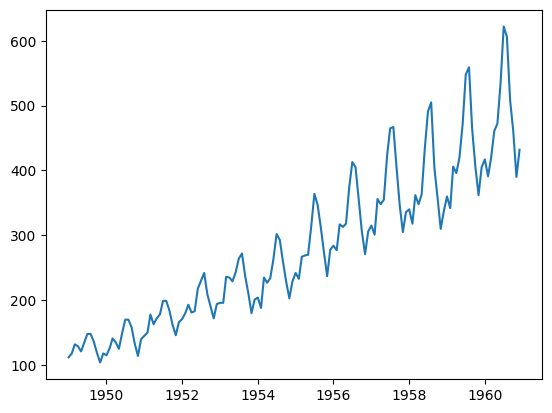

In [ ]:
plt.plot(df)
plt.show()

# seasonal decomposition : take yout time series data as input and decompose it into three main components.
# Trend : the overall direction or pattern in the data over a long period of time
# seasonality:The repeating short cycle in the data (it can be monthly,yearly,or quarterly)
# residual:Noise residual is like a sudden unpredictable change which do not has any correlation

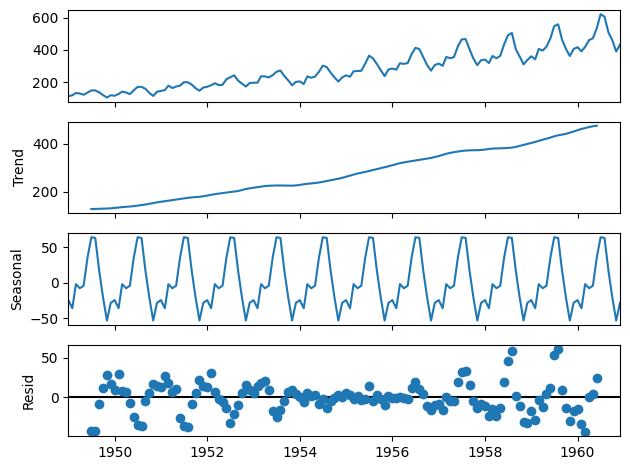

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(df)
decomposed.plot()
plt.show()

#Check whether the data is statinary or not
#adfuller agumented dickey fuller test
# here we need to take Ho or Ha ho is not stationary and ha is stationary should be taken

In [ ]:
# tocheck thedata is stationary or not we need to do this
# null : data is not stationary
# hypo : data is stationary
# if the pvalue is less then 0.05 then "reject the null hypo" # data is stationary
# if pvalue is more thrn 0.05 then "fails to reject the null hypo" # data is not stationary

In [ ]:
from statsmodels.tsa.stattools import adfuller
test_result = adfuller(df)
pval = test_result[1] # here in the one dimensional matrix their are gonna be 4 values and among whcih we are gonna be choosing the 1st indexed
# value
if pval<=0.05:
  print(f"The data is stationary",{pval})
else:
  print(f"The data is not stationary",{pval})

The data is not stationary {np.float64(0.991880243437641)}


#as our data is not stationary we need to convert the data into the stationary # so weneed to stabilize the mean and variance over time
# so we need remove the seasonality and remove the trend

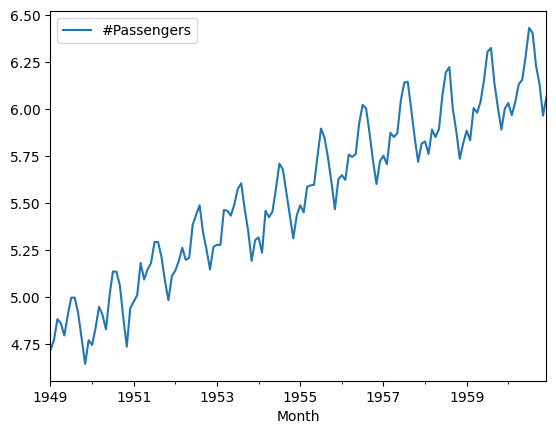

In [ ]:
# logarithmic transformation : so we need to first do this to stabilize the variance
first_log = np.log(df)
first_log.plot()
plt.show()

#rollingmean : this computest the moving average of the timeseires over as specified window, in our case the window size is 12 because of the monthly data we are having

#rolling standaraddeviation : how much variation exists around the rolling mean

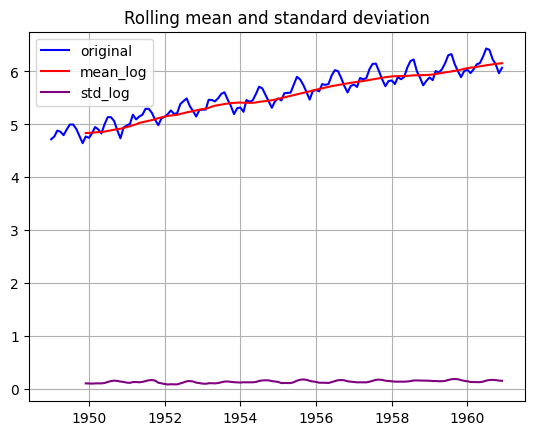

In [ ]:
mean_log = first_log.rolling(window=12).mean() # getting the mean value of the stabilizing values
std_log  = first_log.rolling(window=12).std() # standard deviation of the following data
plt.plot(first_log,color='blue',label='original')
plt.plot(mean_log,color='red',label='mean_log')
plt.plot(std_log,color='purple',label='std_log')
plt.legend(loc='best')
plt.grid(True)
plt.title("Rolling mean and standard deviation")
plt.show()

In [ ]:
mean_log # we have givne the window size tobe 12 so calculating the moving average in this case we it will check that whether their are
# 11 values before it so it not so we will get the values as null and after 12 we will get the values as it is

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,6.124517
1960-09-01,6.132246
1960-10-01,6.142628


In [ ]:
new_data = first_log - mean_log # differencing is done in this case
new_data.dropna(inplace=True)
new_data.head()

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142


#so here we are removing the trend and seasonality becayse the mean is considering for the trend and if we subtract it with the stabilized variance then we will be also removing the trend from it

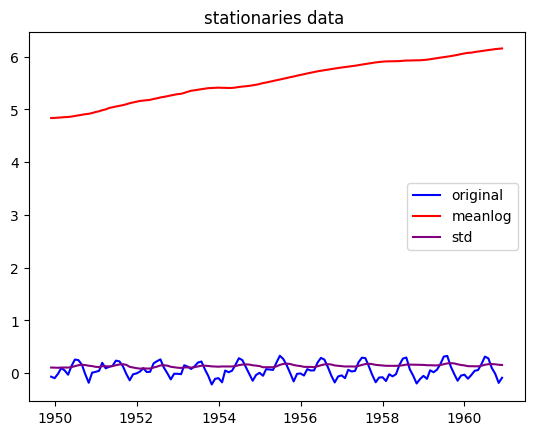

In [ ]:
plt.plot(new_data,color='blue',label='original')
plt.plot(mean_log,color='red',label='meanlog')
plt.plot(std_log,color='purple',label='std')
plt.legend(loc='best')
plt.title("stationaries data ")
plt.show()

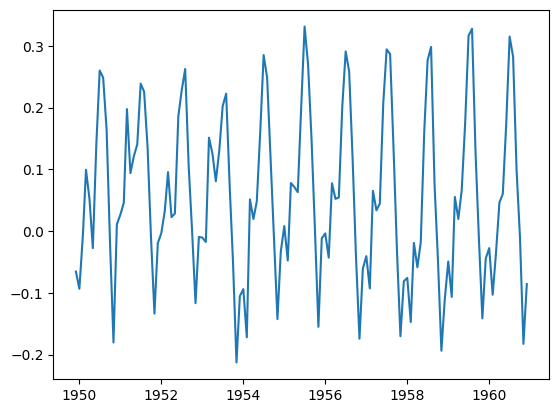

In [ ]:
plt.plot(new_data)

In [ ]:
pval = adfuller(new_data)[1]
pval

np.float64(0.022234630001242206)

In [ ]:
if pval<=0.05:
  print(f"The data is stationary",{pval})
else:
  print(f"The data is not stationary",{pval})

The data is stationary {np.float64(0.022234630001242206)}


#model building

In [ ]:
new_data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [ ]:
# splitting he data
train = new_data.iloc[:120]['#Passengers']
test = new_data.iloc[120:]['#Passengers']

In [ ]:
test

,#Passengers
Month,
1959-12-01,-0.044481
1960-01-01,-0.027530
1960-02-01,-0.103067
1960-03-01,-0.036530
1960-04-01,0.046332
1960-05-01,0.060186
1960-06-01,0.175033
1960-07-01,0.315151
1960-08-01,0.282363


#ARIMA : auto regressive integerated moving average
#p,d,q ⁉
# p : is for the order of lag values
# d : is for the order of differencing (how many time the log transformation is been used)
# q: is for the moving averave  

#P : how many past values u have to consider for prediction
#D : hwo many times you need to subtract the past values to make the data in steady
# Q: how many past errors u want to use toimprove your predictino

In [ ]:
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import *

In [ ]:
import itertools
p = range(0,7)
d = range(0,2)
q = range(0,7)
pdq = list(itertools.product(p,d,q))
rmse = []
orders1 = []
for i in pdq:
    model = ARIMA(train,order = i)
    model_fit = model.fit()
    pred = model_fit.predict(start = len(train),end = len(train)+len(test)-1)
    error = np.sqrt(mean_squared_error(test,pred))
    orders1.append(i)
    rmse.append(error)
results = pd.DataFrame(index=orders1, data=rmse, columns=['rmse'])
results


,rmse
"(0, 0, 0)",0.143339
"(0, 0, 1)",0.140612
"(0, 0, 2)",0.140139
"(0, 0, 3)",0.136974
"(0, 0, 4)",0.140229
...,...
"(6, 1, 2)",0.127791
"(6, 1, 3)",0.127697
"(6, 1, 4)",0.149005
"(6, 1, 5)",0.115909


In [ ]:
results.sort_index(ascending=False)

,rmse
"(6, 1, 6)",0.066423
"(6, 1, 5)",0.115909
"(6, 1, 4)",0.149005
"(6, 1, 3)",0.127697
"(6, 1, 2)",0.127791
...,...
"(0, 0, 4)",0.140229
"(0, 0, 3)",0.136974
"(0, 0, 2)",0.140139
"(0, 0, 1)",0.140612


In [ ]:
A_model = ARIMA(train, order=(6,1,6))
A_model = A_model.fit()  # Assign to variable!
new_data['Arima prediction'] = A_model.predict(start = len(train),end = len(train)+len(test)-1)
new_data.tail()

,#Passengers,Arima prediction
Month,,
1960-08-01,0.282363,0.180773
1960-09-01,0.098235,0.110491
1960-10-01,-0.009230,0.029453
1960-11-01,-0.182690,-0.046373
1960-12-01,-0.085789,-0.097390


<Axes: xlabel='Month'>

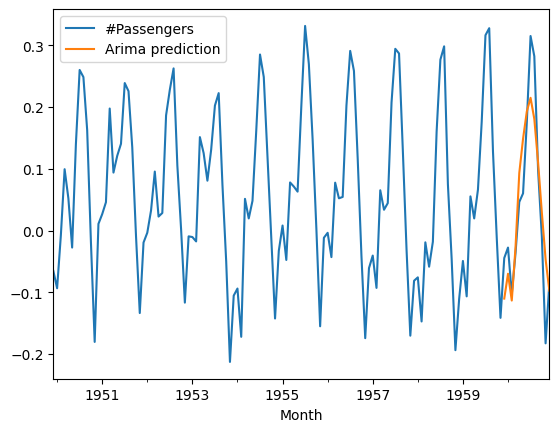

In [ ]:
new_data[["#Passengers","Arima prediction"]].plot()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train,order = (6,1,6),seasonal_order = (6,1,6,12))
model = model.fit()
new_data['sarima prediction'] = model.predict(start = len(train),end = len(train)+len(test)-1)

<Axes: xlabel='Month'>

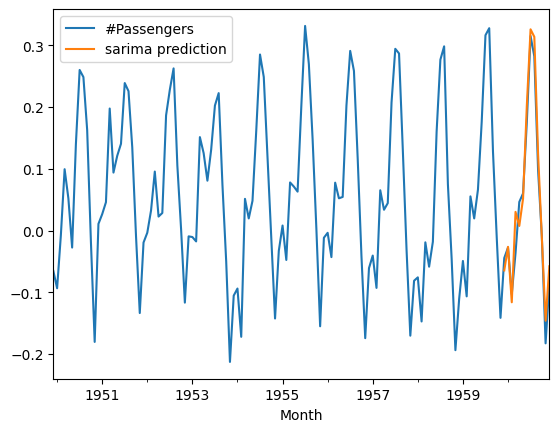

In [ ]:
new_data[['#Passengers','sarima prediction']].plot()

<Axes: xlabel='Month'>

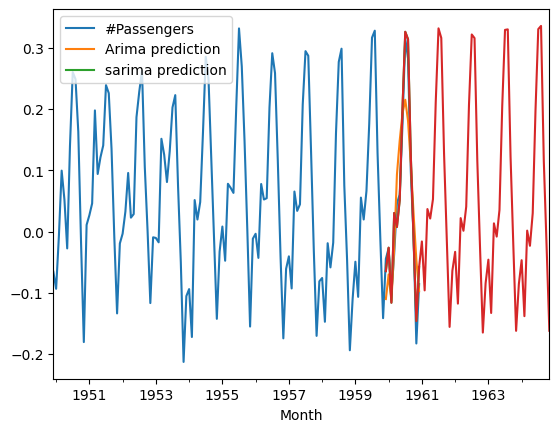

In [ ]:
# if i need to predict for the future then we will do it like this
future = model.forecast(steps=60) # for the next 5 years we are predicting the vaues
new_data.plot()
future.plot()